
---------------------------------------------------------
  Welch's t-test (Schizophrenia vs. Controls)
    ROI     T   dof  cohen-d  p-val  p-corr
0   BA9 -3.16  35.9     0.92  0.003   0.005
1  BA46 -3.21  38.2     0.91  0.003   0.005
2   HIP -0.49  28.1     0.15  0.630   0.630
---------------------------------------------------------



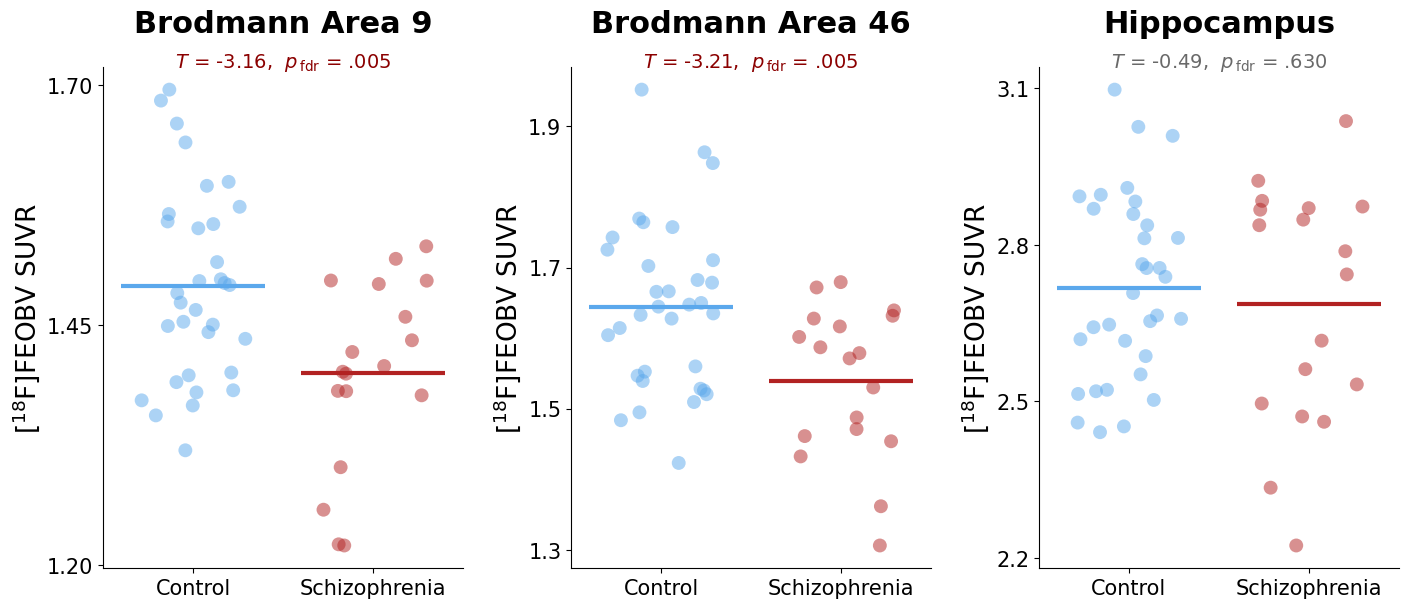

In [13]:
####### Figure 1: Group differences between schizophrenia and control groups, in BA9, BA46, and HIP SUVRs.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg

## Colors
control_color = '#5BA8EC'
patient_color = '#B22222'

## ROI information (including labels and ticks)
ROI_info = {
	'BA9': {'label': 'Brodmann Area 9', 'ROI_ticks': [1.2, 1.45, 1.7]},
	'BA46': {'label': 'Brodmann Area 46', 'ROI_ticks': [1.3, 1.5, 1.7, 1.9]},
	'HIP': {'label': 'Hippocampus', 'ROI_ticks': [2.2, 2.5, 2.8, 3.1]},
}

## Load data
masterfile = pd.read_csv('data/masterfile_final_18patients_and_33controls.csv')

## T-test calculations using pairwise_tests with auto correction
results_list = []

for ROI in ROI_info.keys():
	controls = masterfile[masterfile['Group'] == 'Control'][ROI]
	patients = masterfile[masterfile['Group'] == 'Schizophrenia'][ROI]
	result = pg.ttest(patients, controls, correction='auto')
	result['ROI'] = ROI
	results_list.append(result)

# Combine all results
statitics = pd.concat(results_list, ignore_index=True)

# Apply FDR correction across all tests
statitics['p-corr'] = pg.multicomp(statitics['p-val'].values, method='fdr_bh')[1]

## Print statistics for each ROI
print("\n" + "-"*57)
print("  Welch's t-test (Schizophrenia vs. Controls)")
stats_display = statitics[['ROI', 'T', 'dof', 'cohen-d', 'p-val', 'p-corr']].copy()
stats_display['T'] = stats_display['T'].round(2)
stats_display['dof'] = stats_display['dof'].round(1)
stats_display['cohen-d'] = stats_display['cohen-d'].round(2)
stats_display['p-val'] = stats_display['p-val'].round(3)
stats_display['p-corr'] = stats_display['p-corr'].round(3)
print(stats_display)
print("-"*57 + "\n")

## Create figure with 3 panels
fig, axes = plt.subplots(1, 3, figsize=(15, 7))

# for ax, ROI in zip(axes, ROI_info.keys()):
for roi, (ax, ROI) in enumerate(zip(axes, ROI_info.keys())):
	## Plot group means
	group_means = masterfile.groupby('Group')[ROI].mean()
	for group, mean in group_means.items():
		color = control_color if group == 'Control' else patient_color
		x_position = 0 if group == 'Control' else 1
		ax.hlines(mean, xmin=x_position - 0.4, xmax=x_position + 0.4, color=color, lw=3)

	## Stripplot of individual values
	sns.stripplot(
		data=masterfile, x='Group', y=ROI, jitter=0.3, hue='Group',
		palette=sns.color_palette([control_color, patient_color]),
		alpha=0.5, size=10, ax=ax, dodge=False
	)
	if ax.legend_ is not None:
		ax.legend_.remove()

	## Get T and (FDR) p values
	t_val = statitics.iloc[roi]['T']
	p_val = statitics.iloc[roi]['p-corr']
	significant = p_val < 0.05

	## Format stats text
	stats_color = 'darkred' if significant else 'dimgray'
	t_text = f"$\\mathit{{T}}$ = {t_val:.2f}"
	if p_val < 0.001:
		p_text = r"$\mathit{p}_{\,\mathrm{fdr}}$ < .001"
	else:
		p_str = f"{p_val:.3f}".replace('0.', '.')
		p_text = r"$\mathit{p}_{\,\mathrm{fdr}}$" + f" = {p_str}"
	ax.text(0.5, 1.0,
		f"{t_text},  {p_text}",
		color=stats_color, fontsize=14, ha='center',
		transform=ax.transAxes)
	
	## formatting
	ax.set_title(ROI_info[ROI]['label'], fontsize=22, pad=25, fontweight='bold')
	ax.set_ylabel(r'[$^{18}$F]FEOBV SUVR', fontsize=19)
	ax.set_xlabel('')
	ax.set_yticks(ROI_info[ROI]['ROI_ticks'])
	ax.tick_params(axis='both', labelsize=15)
	sns.despine(ax=ax, top=True, right=True)

## Adjust layout
plt.tight_layout(pad=4.0)
plt.subplots_adjust(wspace=0.3)

## Save & show
plt.savefig('plots/Figure1_Group_difference_in_BA9_BA46_HIP_SUVRs_between_Schizophrenia_and_Controls_with_t-test_stats.png', dpi=700, bbox_inches='tight')
plt.show()